#  PyTorch Lightning

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* https://lightning.ai/docs/pytorch/stable/starter/introduction.html
* https://lightning.ai/docs/pytorch/stable/levels/core_skills.html
* https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.core.LightningModule.html#lightning.pytorch.core.LightningModule.log
* https://lightning.ai/docs/pytorch/stable/extensions/logging.html
* https://lightning.ai/docs/pytorch/stable/common/progress_bar.html
* https://lightning.ai/docs/pytorch/stable/common/early_stopping.html
* https://lightning.ai/docs/pytorch/1.6.3/api/pytorch_lightning.utilities.model_summary.html#pytorch_lightning.utilities.model_summary.ModelSummary
* https://torchmetrics.readthedocs.io/en/stable/pages/lightning.html
* https://pytorch-lightning.readthedocs.io/en/2.1.2/pytorch/
* https://www.youtube.com/watch?v=XbIN9LaQycQ&list=PLhhyoLH6IjfyL740PTuXef4TstxAK6nGP
* https://pytorch-lightning.readthedocs.io/en/2.1.2/pytorch/data/datamodule.html

## Задачи для совместного разбора

1\. Создайте датасет для классификации и обучите модель при помощи PyTorch Lightning.

In [1]:
%pip install pytorch_lightning torchmetrics category_encoders wandb

^C
Note: you may need to restart the kernel to use updated packages.


   ---------------------------------------- 0.0/857.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/857.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/857.3 kB ? eta -:--:--
   ------------ --------------------------- 262.1/857.3 kB ? eta -:--:--
   ------------ --------------------------- 262.1/857.3 kB ? eta -:--:--
   ------------ --------------------------- 262.1/857.3 kB ? eta -:--:--
   ------------ --------------------------- 262.1/857.3 kB ? eta -:--:--
   ------------ --------------------------- 262.1/857.3 kB ? eta -:--:--
   ----------------------- -------------- 524.3/857.3 kB 284.9 kB/s eta 0:00:02
   ----------------------- -------------- 524.3/857.3 kB 284.9 kB/s eta 0:00:02
   ---------------------------------------- 857.3/857.3 kB 398.6 kB/s  0:00:02
   ---------------------------------------- 0.0/25.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/25.0 MB ? eta -:--:--
   ----------------------------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
from typing import Any, Optional
import pytorch_lightning as pl
from sklearn.datasets import make_classification

class MyLightningModule(pl.LightningModule):
    """PyTorch Lightning module for binary classification."""

    def __init__(self, n_features: int = 20, hidden_dim: int = 32, lr: float = 1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.model = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.criterion = nn.BCEWithLogitsLoss()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x).squeeze(-1)

    def _shared_step(self, batch: Any, stage: str) -> torch.Tensor:
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = (torch.sigmoid(logits) >= 0.5).float()
        acc = (preds == y).float().mean()
        self.log(f"{stage}_loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=x.size(0))
        self.log(f"{stage}_acc", acc, on_step=False, on_epoch=True, prog_bar=True, batch_size=x.size(0))
        return loss

    def training_step(self, batch: Any, batch_idx: int) -> torch.Tensor:
        return self._shared_step(batch, "train")

    def validation_step(self, batch: Any, batch_idx: int) -> None:
        self._shared_step(batch, "val")

    def test_step(self, batch: Any, batch_idx: int) -> None:
        self._shared_step(batch, "test")

    def configure_optimizers(self) -> torch.optim.Optimizer:
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

In [7]:
class MyDataModule(pl.LightningDataModule):
    """PyTorch Lightning DataModule for synthetic binary classification."""

    def __init__(self, batch_size: int = 64):
        super().__init__()
        self.batch_size = batch_size
        self.n_features = 20

    def prepare_data(self) -> None:
        pass

    def setup(self, stage: Optional[str] = None) -> None:
        x_np, y_np = make_classification(
            n_samples=2000,
            n_features=self.n_features,
            n_informative=10,
            n_redundant=2,
            random_state=42,
        )
        x = torch.tensor(x_np, dtype=torch.float32)
        y = torch.tensor(y_np, dtype=torch.float32)
        full_dataset = TensorDataset(x, y)
        train_size = int(0.7 * len(full_dataset))
        val_size = int(0.15 * len(full_dataset))
        test_size = len(full_dataset) - train_size - val_size
        self.train_ds, self.val_ds, self.test_ds = random_split(
            full_dataset,
            [train_size, val_size, test_size],
            generator=torch.Generator().manual_seed(42),
        )

    def train_dataloader(self) -> DataLoader:
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self) -> DataLoader:
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self) -> DataLoader:
        return DataLoader(self.test_ds, batch_size=self.batch_size, shuffle=False)

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Загрузите набор данных из файла `Walmart.csv`. Выполните следующую процедуру предобработки:
- замените цены `Weekly_Sales` на логарифм цены;
- удалите столбец с датами;
- закодируйте столбцы `Store` и `Holiday_Flag` при помощи `TargetEncoder` (см. пакет [category_encoders](https://contrib.scikit-learn.org/category_encoders/));
- после кодирование выполните стандартизацию признаков;
- разбейте выборку на обучающее, валидационное и тестовое множество.

Все преобразования допускает делать при помощи `numpy`, `pandas` и `sklearn`.

- [ ] Проверено на семинаре

In [16]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from torch.utils.data import TensorDataset, DataLoader

# Task 1: load and preprocess Walmart data
local_path = "data/Walmart.csv"
fallback_url = "https://raw.githubusercontent.com/selva86/datasets/master/Walmart_Store_sales.csv"

if os.path.exists(local_path):
    df = pd.read_csv(local_path)
else:
    df = pd.read_csv(fallback_url)

df["Weekly_Sales"] = np.log1p(df["Weekly_Sales"])
y = df["Weekly_Sales"].copy()
X = df.drop(columns=["Weekly_Sales", "Date"])

encoder = TargetEncoder(cols=["Store", "Holiday_Flag"] )
X_encoded = encoder.fit_transform(X, y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_scaled, y.values, test_size=0.2, random_state=42
 )
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_train_np, y_train_np, test_size=0.25, random_state=42
 )

X_train_t = torch.tensor(X_train_np, dtype=torch.float32)
X_val_t = torch.tensor(X_val_np, dtype=torch.float32)
X_test_t = torch.tensor(X_test_np, dtype=torch.float32)
y_train_t = torch.tensor(y_train_np, dtype=torch.float32)
y_val_t = torch.tensor(y_val_np, dtype=torch.float32)
y_test_t = torch.tensor(y_test_np, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

print(f"Train: {len(X_train_t)}, Val: {len(X_val_t)}, Test: {len(X_test_t)}")


Train: 3861, Val: 1287, Test: 1287


<p class="task" id="2"></p>

2\. В ячейках ниже представлен шаблонный код для обучения модели. В данной версии все реализовано "с нуля": обучение, метрики, визуализация, логирование, логика ранней остановки.

Используя набор данных из предыдущего задания, обучите модель, используя предложенную реализацию. Визуализируйте динамику изменения среднего значения функции потерь и метрик на обучающем и валидационном множестве. Интегрируйте реализацию ранней остановки в цикл обучения. Посчитайте и выведите на экран значения метрик на тестовом множестве.

- [ ] Проверено на семинаре

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def r2_score(y_true, y_pred):
    total_sum_squares = torch.sum((y_true - y_true.mean())**2)
    residual_sum_squares = torch.sum((y_true - y_pred)**2)
    r2 = 1 - (residual_sum_squares / total_sum_squares)
    return r2

def mape_score(y_true, y_pred):
    return torch.mean(torch.abs((y_true - y_pred) / y_true)) * 100

In [10]:
class RegressionModel(nn.Module):
    def __init__(self, n_inputs, h_hidden):
        super().__init__()
        self.fc1 = nn.Linear(n_inputs, h_hidden)
        self.fc2 = nn.Linear(h_hidden, 1)
    
    def forward(self, x):
        out = self.fc1(x)
        out = out.relu()
        out = self.fc2(out)
        return out


In [11]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [12]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, early_stopping):
    train_losses = []
    val_losses = []
    train_r2s = []
    val_r2s = []
    train_mapes = []
    val_mapes = []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_r2 = 0.0
        train_mape = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs).flatten()
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_r2 += r2_score(targets, outputs).item()
            train_mape += mape_score(targets, outputs).item()

        train_loss /= len(train_loader)
        train_r2 /= len(train_loader)
        train_mape /= len(train_loader)

        train_losses.append(train_loss)
        train_r2s.append(train_r2)
        train_mapes.append(train_mape)

        model.eval()
        val_loss = 0.0
        val_r2 = 0.0
        val_mape = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs).flatten()
                loss = criterion(outputs, targets)
                val_loss += loss.item()
                val_r2 += r2_score(targets, outputs).item()
                val_mape += mape_score(targets, outputs).item()

        val_loss /= len(val_loader)
        val_r2 /= len(val_loader)
        val_mape /= len(val_loader)

        val_losses.append(val_loss)
        val_r2s.append(val_r2)
        val_mapes.append(val_mape)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        early_stopping(val_loss)
        if early_stopping.early_stop:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            break

    return train_losses, val_losses, train_r2s, val_r2s, train_mapes, val_mapes

Epoch 1/100, Train Loss: 30.4652, Val Loss: 1.2695
Epoch 2/100, Train Loss: 0.7509, Val Loss: 0.4226
Epoch 3/100, Train Loss: 0.2989, Val Loss: 0.2014
Epoch 4/100, Train Loss: 0.1503, Val Loss: 0.1138
Epoch 5/100, Train Loss: 0.0842, Val Loss: 0.0677
Epoch 6/100, Train Loss: 0.0529, Val Loss: 0.0472
Epoch 7/100, Train Loss: 0.0436, Val Loss: 0.0423
Epoch 8/100, Train Loss: 0.0341, Val Loss: 0.0308
Epoch 9/100, Train Loss: 0.0293, Val Loss: 0.0259
Epoch 10/100, Train Loss: 0.0246, Val Loss: 0.0260
Epoch 11/100, Train Loss: 0.0235, Val Loss: 0.0240
Epoch 12/100, Train Loss: 0.0215, Val Loss: 0.0251
Epoch 13/100, Train Loss: 0.0208, Val Loss: 0.0229
Epoch 14/100, Train Loss: 0.0194, Val Loss: 0.0222
Epoch 15/100, Train Loss: 0.0197, Val Loss: 0.0202
Epoch 16/100, Train Loss: 0.0186, Val Loss: 0.0208
Epoch 17/100, Train Loss: 0.0186, Val Loss: 0.0220
Epoch 18/100, Train Loss: 0.0181, Val Loss: 0.0181
Epoch 19/100, Train Loss: 0.0198, Val Loss: 0.0209
Epoch 20/100, Train Loss: 0.0181, Val L

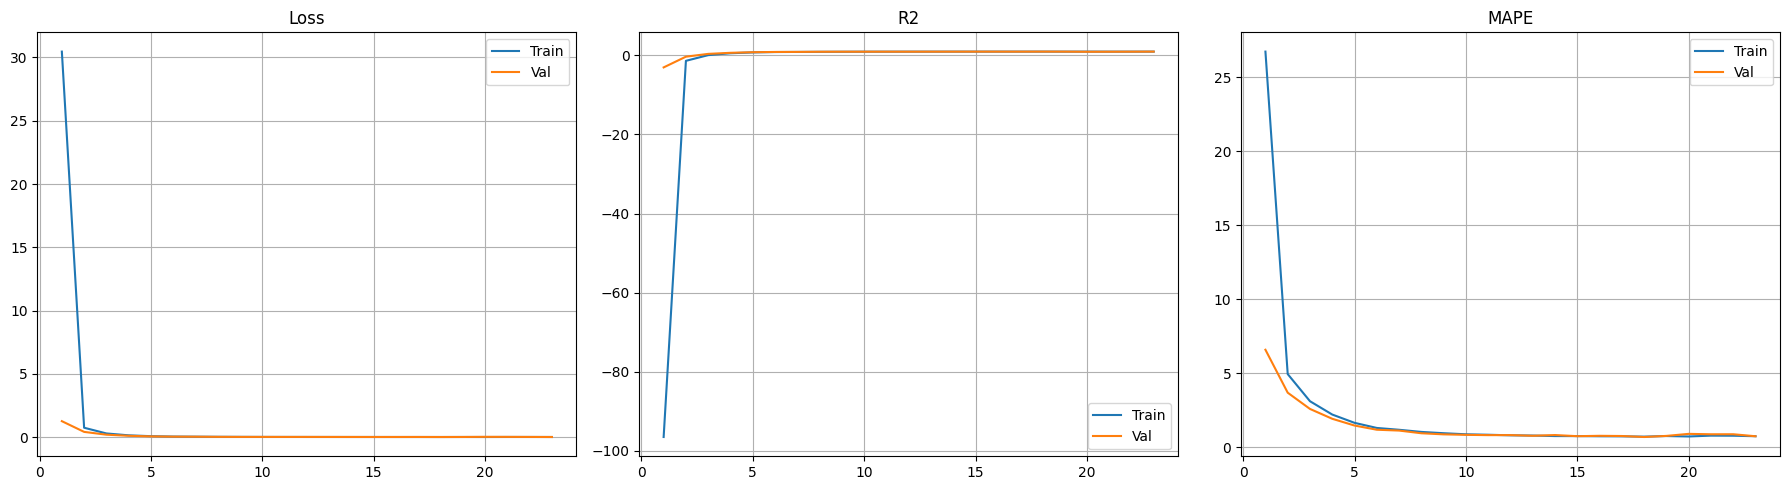

Test Loss: 0.0181 | Test R2: 0.9448 | Test MAPE: 0.74%


In [18]:
# Task 2: train from-scratch model with early stopping
batch_size = 32
learning_rate = 0.01
patience = 5
num_epochs = 100
model = RegressionModel(n_inputs=X_train_t.shape[1], h_hidden=64)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
early_stopping = EarlyStopping(patience=patience, min_delta=1e-5)

train_losses, val_losses, train_r2s, val_r2s, train_mapes, val_mapes = train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epochs, early_stopping
 )

epochs_range = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, train_losses, label="Train")
axes[0].plot(epochs_range, val_losses, label="Val")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid()

axes[1].plot(epochs_range, train_r2s, label="Train")
axes[1].plot(epochs_range, val_r2s, label="Val")
axes[1].set_title("R2")
axes[1].legend()
axes[1].grid()

axes[2].plot(epochs_range, train_mapes, label="Train")
axes[2].plot(epochs_range, val_mapes, label="Val")
axes[2].set_title("MAPE")
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()

model.eval()
test_loss = 0.0
test_r2 = 0.0
test_mape = 0.0
with torch.no_grad():
    for inputs, targets in test_loader:
        outputs = model(inputs).flatten()
        test_loss += criterion(outputs, targets).item()
        test_r2 += r2_score(targets, outputs).item()
        test_mape += mape_score(targets, outputs).item()

test_loss /= len(test_loader)
test_r2 /= len(test_loader)
test_mape /= len(test_loader)

print(f"Test Loss: {test_loss:.4f} | Test R2: {test_r2:.4f} | Test MAPE: {test_mape:.2f}%")

<p class="task" id="3"></p>

3\. Перепишите логику обучения модели, используя `pytorch_lightning`. Для расчета метрик $R^2$ и MAPE используйте `torchmetrics`. Ранняя остановка в данном задании не требуется. После завершения обучения посчитайте значения метрик на тестовом множестве.

В процессе обучения настройки progressbar так, что:
* для каждого батча во время обучения рассчитывается значение функции потерь и метрик, по завершению эпохи показатели усредняются;
* для каждого батча во время валидации рассчитывается значение функции потерь и метрик, по завершению эпохи показатели усредняются.

- [ ] Проверено на семинаре

In [19]:
import os
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping as PLEarlyStopping
from pytorch_lightning.loggers import WandbLogger
from torchmetrics.regression import R2Score, MeanAbsolutePercentageError

class LightningRegressor(pl.LightningModule):
    def __init__(self, n_inputs, h_hidden=64, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.model = nn.Sequential(
            nn.Linear(n_inputs, h_hidden),
            nn.ReLU(),
            nn.Linear(h_hidden, 1),
        )
        self.criterion = nn.MSELoss()
        self.train_r2 = R2Score()
        self.val_r2 = R2Score()
        self.test_r2 = R2Score()
        self.train_mape = MeanAbsolutePercentageError()
        self.val_mape = MeanAbsolutePercentageError()
        self.test_mape = MeanAbsolutePercentageError()

    def forward(self, x):
        return self.model(x).flatten()

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        r2 = self.train_r2(y_hat, y)
        mape = self.train_mape(y_hat, y) * 100
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=x.size(0))
        self.log("train_r2", r2, on_step=False, on_epoch=True, prog_bar=True, batch_size=x.size(0))
        self.log("train_mape", mape, on_step=False, on_epoch=True, prog_bar=True, batch_size=x.size(0))
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        r2 = self.val_r2(y_hat, y)
        mape = self.val_mape(y_hat, y) * 100
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=x.size(0))
        self.log("val_r2", r2, on_step=False, on_epoch=True, prog_bar=True, batch_size=x.size(0))
        self.log("val_mape", mape, on_step=False, on_epoch=True, prog_bar=True, batch_size=x.size(0))

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        r2 = self.test_r2(y_hat, y)
        mape = self.test_mape(y_hat, y) * 100
        self.log("test_loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=x.size(0))
        self.log("test_r2", r2, on_step=False, on_epoch=True, prog_bar=True, batch_size=x.size(0))
        self.log("test_mape", mape, on_step=False, on_epoch=True, prog_bar=True, batch_size=x.size(0))

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.hparams.lr)

# Task 3: Lightning training without early stopping
model_l3 = LightningRegressor(n_inputs=X_train_t.shape[1], h_hidden=64, lr=learning_rate)
trainer_l3 = pl.Trainer(
    max_epochs=num_epochs,
    logger=False,
    enable_checkpointing=False,
    enable_model_summary=False,
    log_every_n_steps=1,
 )
trainer_l3.fit(model_l3, train_loader, val_loader)
task3_test_metrics = trainer_l3.test(model_l3, dataloaders=test_loader, verbose=False)
print("Task 3 test metrics:", task3_test_metrics)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

c:\Users\alexm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21:
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

c:\Users\alexm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\trainer\connectors\data_
connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

c:\Users\alexm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\trainer\connectors\data_
connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=100` reached.


Output()

Task 3 test metrics: [{'test_loss': 0.01778109185397625, 'test_r2': 0.9457859992980957, 'test_mape': 0.6919806003570557}]


<p class="task" id="4"></p>

4\. Повторите задачу 3, добавив логику ранней остановки, используя callback `pytorch_lightning`. Если значение функции потерь на валидационном множестве не улучшалось в течении 5 эпох, происходит ранняя остановка.

- [ ] Проверено на семинаре

In [20]:
# Task 4: Lightning with early stopping callback
early_stop_cb = PLEarlyStopping(monitor="val_loss", patience=5, mode="min")
model_l4 = LightningRegressor(n_inputs=X_train_t.shape[1], h_hidden=64, lr=learning_rate)
trainer_l4 = pl.Trainer(
    max_epochs=num_epochs,
    callbacks=[early_stop_cb],
    logger=False,
    enable_checkpointing=False,
    enable_model_summary=False,
    log_every_n_steps=1,
 )
trainer_l4.fit(model_l4, train_loader, val_loader)
task4_test_metrics = trainer_l4.test(model_l4, dataloaders=test_loader, verbose=False)
print("Task 4 test metrics:", task4_test_metrics)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

Output()

Task 4 test metrics: [{'test_loss': 0.015381118282675743, 'test_r2': 0.9534616470336914, 'test_mape': 0.6416397094726562}]


<p class="task" id="5"></p>

5\. Повторите задачу 4, оформив набор данных в виде `pytorch_lightning.LightningDataModule`. Всю логику по созданию датасета (преобразования признаков, разбиение и т.д.) запакуйте в метод `setup`. 

- [ ] Проверено на семинаре

In [22]:

# Task 5: DataModule with setup preprocessing logic
class WalmartDataModule(pl.LightningDataModule):
    def __init__(self, csv_path="data/Walmart.csv", batch_size=32):
        super().__init__()
        self.csv_path = csv_path
        self.batch_size = batch_size

    def prepare_data(self):
        pass

    def setup(self, stage: Optional[str] = None):
        fallback_url = "https://raw.githubusercontent.com/selva86/datasets/master/Walmart_Store_sales.csv"
        if os.path.exists(self.csv_path):
            df_local = pd.read_csv(self.csv_path)
        else:
            df_local = pd.read_csv(fallback_url)

        df_local["Weekly_Sales"] = np.log1p(df_local["Weekly_Sales"])
        y_local = df_local["Weekly_Sales"].copy()
        X_local = df_local.drop(columns=["Weekly_Sales", "Date"])
        enc_local = TargetEncoder(cols=["Store", "Holiday_Flag"])
        X_local = enc_local.fit_transform(X_local, y_local)
        scl_local = StandardScaler()
        X_local = scl_local.fit_transform(X_local)

        X_train_np_local, X_test_np_local, y_train_np_local, y_test_np_local = train_test_split(
            X_local, y_local.values, test_size=0.2, random_state=42
        )
        X_train_np_local, X_val_np_local, y_train_np_local, y_val_np_local = train_test_split(
            X_train_np_local, y_train_np_local, test_size=0.25, random_state=42
        )

        self.train_ds = TensorDataset(
            torch.tensor(X_train_np_local, dtype=torch.float32),
            torch.tensor(y_train_np_local, dtype=torch.float32),
        )
        self.val_ds = TensorDataset(
            torch.tensor(X_val_np_local, dtype=torch.float32),
            torch.tensor(y_val_np_local, dtype=torch.float32),
        )
        self.test_ds = TensorDataset(
            torch.tensor(X_test_np_local, dtype=torch.float32),
            torch.tensor(y_test_np_local, dtype=torch.float32),
        )
        self.n_features = self.train_ds.tensors[0].shape[1]

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.batch_size, shuffle=False)

dm = WalmartDataModule(batch_size=batch_size)
dm.setup()

model_l5 = LightningRegressor(n_inputs=dm.n_features, h_hidden=64, lr=learning_rate)
trainer_l5 = pl.Trainer(
    max_epochs=num_epochs,
    callbacks=[PLEarlyStopping(monitor="val_loss", patience=5, mode="min")],
    logger=False,
    enable_checkpointing=False,
    enable_model_summary=False,
    log_every_n_steps=1,
 )
trainer_l5.fit(model_l5, datamodule=dm)
task5_test_metrics = trainer_l5.test(model_l5, datamodule=dm, verbose=False)
print("Task 5 test metrics:", task5_test_metrics)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

c:\Users\alexm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21:
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

c:\Users\alexm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\trainer\connectors\data_
connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

c:\Users\alexm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\trainer\connectors\data_
connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

Output()

c:\Users\alexm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\alexm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Task 5 test metrics: [{'test_loss': 0.021342748776078224, 'test_r2': 0.9353168606758118, 'test_mape': 0.8084822297096252}]


<p class="task" id="6"></p>

6\. Повторите задачу 5, добавив логирование при помощи `wandb`. 

Вставьте в текстовую ячейку скриншоты, демонстрирующие интерфейс `wandb` со всеми нужными визуализациями.

- [ ] Проверено на семинаре

In [23]:

# Task 6: W&B logging (offline mode) + DataModule + early stopping
os.environ["WANDB_SILENT"] = "true"
wandb_logger = WandbLogger(project="03-3-lightning-walmart", name="task6-offline", mode="offline")
model_l6 = LightningRegressor(n_inputs=dm.n_features, h_hidden=64, lr=learning_rate)
trainer_l6 = pl.Trainer(
    max_epochs=num_epochs,
    callbacks=[PLEarlyStopping(monitor="val_loss", patience=5, mode="min")],
    logger=wandb_logger,
    enable_checkpointing=False,
    enable_model_summary=False,
    log_every_n_steps=1,
 )
trainer_l6.fit(model_l6, datamodule=dm)
task6_test_metrics = trainer_l6.test(model_l6, datamodule=dm, verbose=False)
print("Task 6 test metrics:", task6_test_metrics)

try:
    import wandb
    wandb.finish()
except Exception:
    pass

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.


ServicePollForTokenError: Failed to read port info after 30.0 seconds.